# GPS + IMU Sensor Fusion for Trajectory Estimation
### Implementation Notebook — Step-by-Step in Google Colab

**Author:** Prem M Patel | Computer Engineering | Sankalchand Patel University  
**Contact:** prempatel7740@gmail.com

---

> **Before you start:** Make sure you have read the Theory Notebook first.  
> Every cell here directly implements a concept explained there.  
> Read the markdown above each cell before running it.

---

### What We Are Building

A complete navigation pipeline that:
1. Loads real IMU + GPS sensor data from a walking person
2. Cleans the noisy sensor signals
3. Fuses GPS + IMU using a Kalman Filter
4. Trains an LSTM to predict position when GPS is lost
5. Visualises everything on an interactive map

**Estimated total runtime: ~15 minutes on Colab free tier**

---

### Quick Tip — GPU
Before running anything, enable GPU for faster LSTM training:  
`Runtime → Change runtime type → T4 GPU → Save`

---
## Step 1 — Install Libraries and Import Everything

We install two libraries that do not come pre-installed in Colab:
- `filterpy` — provides the Kalman Filter implementation
- `folium` — creates interactive map visualisations

Everything else (numpy, pandas, matplotlib, tensorflow, scipy) is already available in Colab.

In [2]:
#1 — Install required libraries
!pip install filterpy folium tensorflow --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


---
## Step 2 — Download the ADVIO Dataset

We download sequence `advio-01` from Zenodo (the official research data repository).  
This is one recording session — a person walking through real indoor/outdoor environments in Finland.

**Size: ~120 MB. This takes 3–5 minutes on a standard Colab connection.**

The zip extracts to a folder with subfolders:
- `iphone/` — all raw sensor CSV files  
- `ground-truth/` — high-accuracy reference position

> If the download fails, re-run this cell. Zenodo occasionally has slow response times.

In [3]:
# 2 — Download ADVIO Dataset (sequence 01 to start)
import os

# We'll start with just advio-01 (one sequence ~100MB) to test the pipeline
# Once everything works, you can download more sequences

DATA_DIR = '/content/advio-01'

# Remove existing directory if it exists to ensure a fresh download
if os.path.exists(DATA_DIR):
    print(f'Removing existing directory: {DATA_DIR}')
    import shutil
    shutil.rmtree(DATA_DIR)

# Create a general directory for downloads if it doesn't exist, though not strictly needed for this fix.
!mkdir -p /content/

# Download advio-01 from the official ADVIO Zenodo record 1476931
# Note: The original URL (record 3753921) was incorrect or problematic.
print(' Downloading ADVIO advio-01 (~120 MB, takes 3-5 min)...')
!wget --no-check-certificate -q --show-progress -O /content/advio-01.zip \
  "https://zenodo.org/record/1476931/files/advio-01.zip"

# Verify the downloaded file is actually a zip before extracting
import subprocess
result = subprocess.run(['file', '/content/advio-01.zip'], capture_output=True, text=True)
print(f'File type: {result.stdout.strip()}')

if 'Zip' in result.stdout or 'zip' in result.stdout:
    print(' Valid zip file — extracting...')
    # Extract directly to /content/ so advio-01 folder is at /content/advio-01
    !unzip -q /content/advio-01.zip -d /content/
    !rm /content/advio-01.zip
    print(' Extracted successfully')
else:
    print(' Download failed — file is not a valid zip')
    print('   Check your internet connection and try running this cell again')
    # Optionally, provide manual download instructions here if automated fails frequently

# Check what files are inside the extracted directory
print('\nChecking extracted files:')
if os.path.exists(f'{DATA_DIR}/iphone'):
    for f in os.listdir(f'{DATA_DIR}/iphone'):
        print(f'    {f}')
else:
    print(f'    {DATA_DIR}/iphone directory not found. Extraction might have failed.')

/content/advio-01.z 100%[===================>] 189.79M  15.1MB/s    in 13s     
File type: /content/advio-01.zip: Zip archive data, at least v1.0 to extract, compression method=store
 Valid zip file — extracting...
 Extracted successfully

Checking extracted files:
    gyro.csv
    frames.csv
    magnetometer.csv
    frames.mov
    platform-locations.csv
    accelerometer.csv
    arkit.csv
    barometer.csv


---
## Step 3 — Load the Sensor Data

We load four CSV files into pandas DataFrames. Each file has no header row — just raw numbers — so we manually name the columns.

**What to check after running:**
- Accelerometer and gyroscope should have ~26,000 rows (100 Hz × ~260 seconds)
- GPS should have ~260 rows (1 Hz × ~260 seconds)
- Accelerometer Y should hover around 9.8 m/s² — that is gravity acting on the phone

In [4]:
# 3 — Load IMU and GPS Data

# Load accelerometer data
acc = pd.read_csv('/content/advio-01/iphone/accelerometer.csv',
                  header=None,
                  names=['time', 'acc_x', 'acc_y', 'acc_z'])

# Load gyroscope data
gyro = pd.read_csv('/content/advio-01/iphone/gyro.csv', # Corrected filename from gyroscope.csv to gyro.csv
                   header=None,
                   names=['time', 'gyro_x', 'gyro_y', 'gyro_z'])

# Load GPS data
gps = pd.read_csv('/content/advio-01/iphone/platform-locations.csv', # Corrected filename from platform-location.csv to platform-locations.csv
                  header=None,
                  names=['time', 'lat', 'lon', 'alt', 'accuracy'])

# Load ground truth
gt = pd.read_csv('/content/advio-01/ground-truth/pose.csv',
                 header=None,
                 names=['time', 'pos_x', 'pos_y', 'pos_z', 'q1', 'q2', 'q3', 'q4'])

# Quick check
print("Accelerometer shape:", acc.shape)
print("Gyroscope shape:    ", gyro.shape)
print("GPS shape:          ", gps.shape)
print("Ground Truth shape: ", gt.shape)

print("\n--- Accelerometer sample ---")
print(acc.head(3))

print("\n--- GPS sample ---")
print(gps.head(3))

Accelerometer shape: (26638, 4)
Gyroscope shape:     (25971, 4)
GPS shape:           (26, 5)
Ground Truth shape:  (26000, 8)

--- Accelerometer sample ---
       time     acc_x     acc_y     acc_z
0  0.007932 -0.728685  8.044571  6.028114
1  0.017697 -0.644410  8.045469  5.911657
2  0.027463 -0.604742  8.087981  5.776787

--- GPS sample ---
               time       lat  lon       alt  accuracy
0.139627   60.16947  24.93365   65  25.85272  12.42330
6.549379   60.16952  24.93377   65  24.88604  11.74505
12.554450  60.16953  24.93378   65  24.24883  11.31996


---
## Step 4 — Visualise the Raw Sensor Data

Before touching the data, always look at it. This step shows you what the raw sensor signals look like — noisy, messy, real.

**Three plots:**
1. **Accelerometer** — Y axis dominated by gravity (~9.8 m/s²), spikes from footsteps visible
2. **Gyroscope** — mostly near zero, sharp spikes when turning corners
3. **GPS** — barely changes because the person only walked a few hundred metres

> The accelerometer and gyroscope noise you see is exactly what the Butterworth filter will clean in the next step.

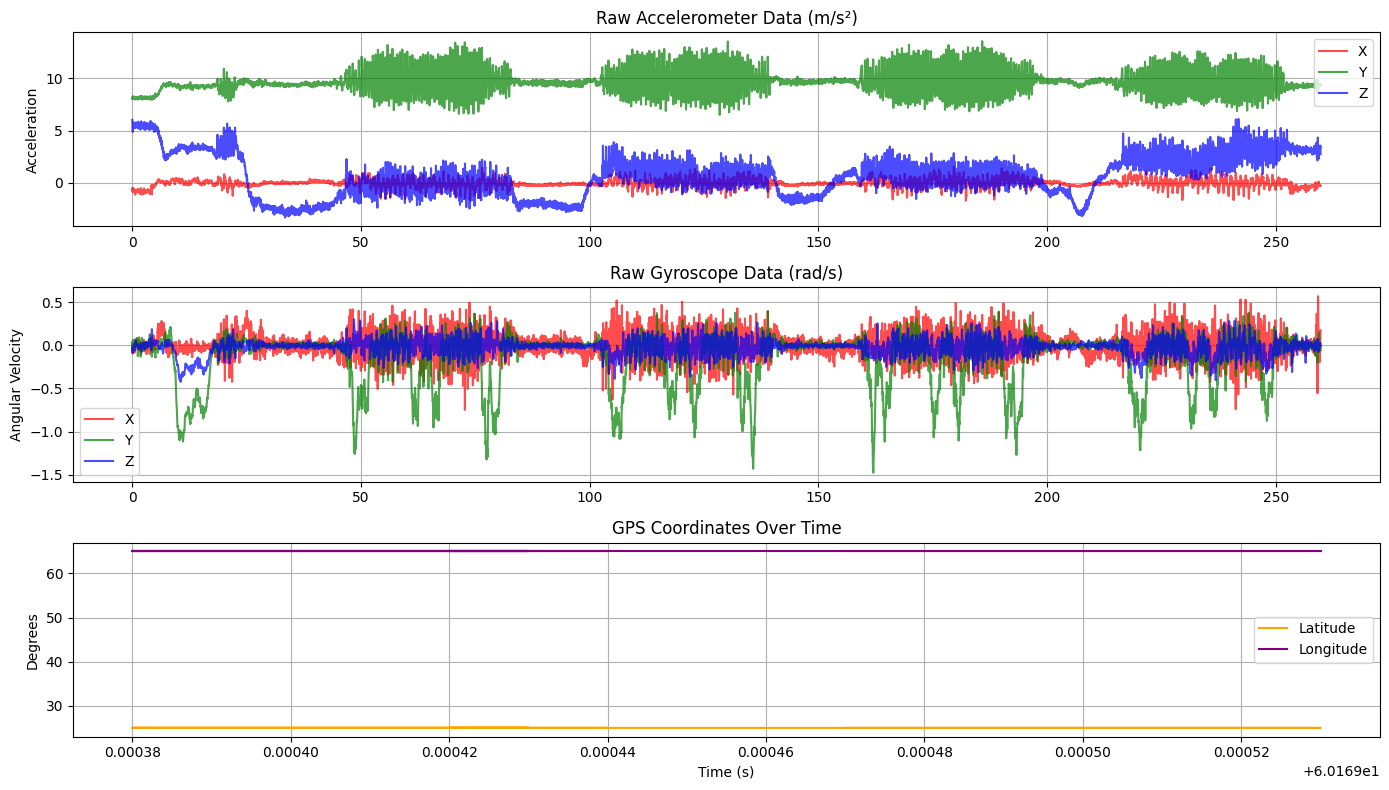

Raw data visualization complete!


In [5]:
# 4 — Visualize Raw Sensor Data

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# --- Plot 1: Accelerometer ---
axes[0].plot(acc['time'], acc['acc_x'], label='X', color='red',   alpha=0.7)
axes[0].plot(acc['time'], acc['acc_y'], label='Y', color='green', alpha=0.7)
axes[0].plot(acc['time'], acc['acc_z'], label='Z', color='blue',  alpha=0.7)
axes[0].set_title('Raw Accelerometer Data (m/s²)')
axes[0].set_ylabel('Acceleration')
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: Gyroscope ---
axes[1].plot(gyro['time'], gyro['gyro_x'], label='X', color='red',   alpha=0.7)
axes[1].plot(gyro['time'], gyro['gyro_y'], label='Y', color='green', alpha=0.7)
axes[1].plot(gyro['time'], gyro['gyro_z'], label='Z', color='blue',  alpha=0.7)
axes[1].set_title('Raw Gyroscope Data (rad/s)')
axes[1].set_ylabel('Angular Velocity')
axes[1].legend()
axes[1].grid(True)

# --- Plot 3: GPS coordinates over time ---
axes[2].plot(gps['time'], gps['lat'], label='Latitude',  color='orange')
axes[2].plot(gps['time'], gps['lon'], label='Longitude', color='purple')
axes[2].set_title('GPS Coordinates Over Time')
axes[2].set_ylabel('Degrees')
axes[2].set_xlabel('Time (s)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('raw_sensor_data.png', dpi=150)
plt.show()

print("Raw data visualization complete!")

---
## Step 5 — Remove Noise with a Low-Pass Filter

Raw IMU data contains high-frequency vibration noise that has nothing to do with actual movement. We apply a 4th-order Butterworth low-pass filter with a 5 Hz cutoff to both accelerometer and gyroscope.

**What the filter does:**
- Frequencies below 5 Hz (real walking motion) → pass through unchanged
- Frequencies above 5 Hz (vibration noise) → removed

**What to check after running:**
- The plot shows raw (faint pink) vs filtered (solid blue) accelerometer X
- The blue line should follow the general trend of the pink but without extreme spikes
- New columns `acc_x_filt`, `acc_y_filt`, `acc_z_filt` appear in the dataframe
- We keep the raw columns too — never destroy original data

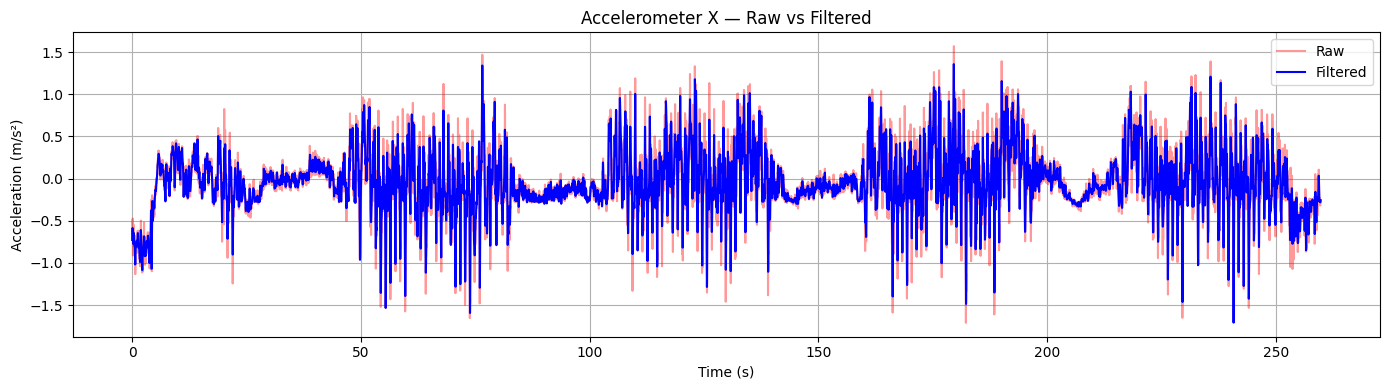

Filtering complete!
New acc columns:   ['time', 'acc_x', 'acc_y', 'acc_z', 'acc_x_filt', 'acc_y_filt', 'acc_z_filt']
New gyro columns:  ['time', 'gyro_x', 'gyro_y', 'gyro_z', 'gyro_x_filt', 'gyro_y_filt', 'gyro_z_filt']


In [6]:
#5 — Low-Pass Filter to Remove IMU Noise

from scipy.signal import butter, filtfilt

def low_pass_filter(data, cutoff=5.0, fs=100.0, order=4):
    """
    Apply a low-pass Butterworth filter to remove high-frequency noise.
    cutoff : frequency threshold (Hz) — signals above this are removed
    fs     : sampling frequency of IMU (~100Hz)
    order  : filter strength
    """
    nyq = 0.5 * fs                  # Nyquist frequency
    normal_cutoff = cutoff / nyq    # Normalize cutoff
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# Apply filter to accelerometer
acc['acc_x_filt'] = low_pass_filter(acc['acc_x'])
acc['acc_y_filt'] = low_pass_filter(acc['acc_y'])
acc['acc_z_filt'] = low_pass_filter(acc['acc_z'])

# Apply filter to gyroscope
gyro['gyro_x_filt'] = low_pass_filter(gyro['gyro_x'])
gyro['gyro_y_filt'] = low_pass_filter(gyro['gyro_y'])
gyro['gyro_z_filt'] = low_pass_filter(gyro['gyro_z'])

# --- Plot: Before vs After filtering (acc_x only) ---
plt.figure(figsize=(14, 4))
plt.plot(acc['time'], acc['acc_x'],      label='Raw',      color='red',  alpha=0.4)
plt.plot(acc['time'], acc['acc_x_filt'], label='Filtered', color='blue', linewidth=1.5)
plt.title('Accelerometer X — Raw vs Filtered')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('filtered_signal.png', dpi=150)
plt.show()

print("Filtering complete!")
print("New acc columns:  ", list(acc.columns))
print("New gyro columns: ", list(gyro.columns))

---
## Step 6 — Synchronise IMU and GPS onto the Same Timeline

IMU fires 100 times per second. GPS fires once per second. They cannot be combined directly because they exist at different timestamps.

**What we do:**
1. Subtract the first timestamp from all sensors so every sensor starts at t=0
2. Use linear interpolation to estimate GPS position at every IMU timestamp
3. Build one unified `synced` DataFrame with all sensors aligned

**What to check after running:**
- Shape should be (26638, 9) — all IMU rows, 9 columns
- The plot shows sparse red dots (original 1 Hz GPS) filled in by a smooth blue line (interpolated 100 Hz)
- Every row now has both IMU readings AND a GPS position

Synchronized dataframe shape: (26638, 9)

Sample rows:
       time     acc_x     acc_y     acc_z    gyro_x    gyro_y    gyro_z  \
0  0.000000 -0.727697  8.043394  6.023003 -0.035033  0.035973 -0.054529   
1  0.009765 -0.689415  8.076452  5.875967 -0.028992  0.019665 -0.055056   
2  0.019531 -0.654315  8.108458  5.734464 -0.023436  0.004584 -0.055301   
3  0.029297 -0.624803  8.138376  5.603023 -0.018835 -0.008284 -0.055067   
4  0.039062 -0.602814  8.165297  5.485765 -0.015557 -0.018164 -0.054231   

    gps_lat  gps_lon  
0  24.93354     65.0  
1  24.93354     65.0  
2  24.93354     65.0  
3  24.93354     65.0  
4  24.93354     65.0  


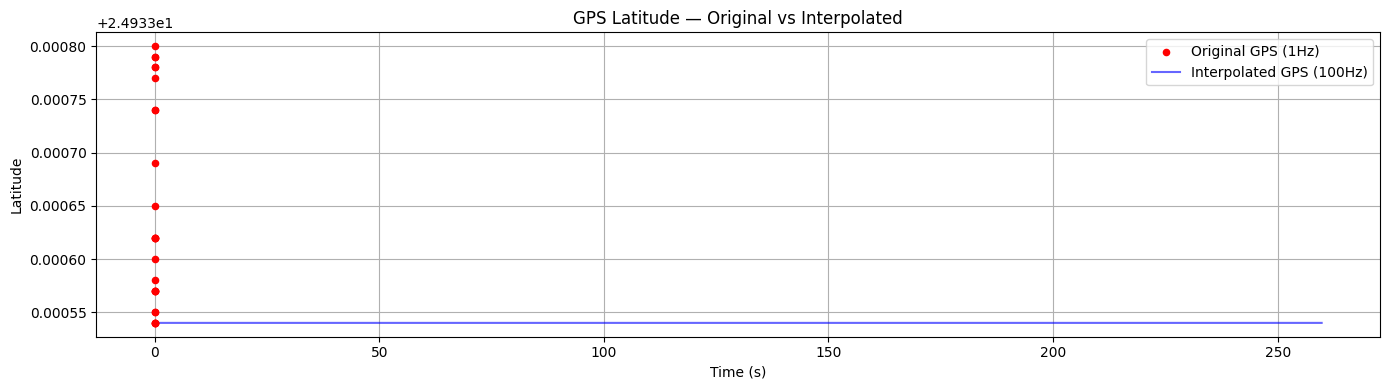


 Sync complete! All sensors now on same timeline.


In [7]:
#6 — Synchronize IMU (100Hz) with GPS (1Hz)

# --- Step 1: Normalize all timestamps to start from 0 ---
acc['time']  = acc['time']  - acc['time'].iloc[0]
gyro['time'] = gyro['time'] - gyro['time'].iloc[0]
gps['time']  = gps['time']  - gps['time'].iloc[0]
gt['time']   = gt['time']   - gt['time'].iloc[0]

# --- Step 2: Interpolate GPS to match IMU timestamps ---
# GPS updates at ~1Hz, IMU at ~100Hz
# We interpolate GPS lat/lon so every IMU timestamp has a GPS value

from numpy import interp

gps_lat_interp = interp(acc['time'], gps['time'], gps['lat'])
gps_lon_interp = interp(acc['time'], gps['time'], gps['lon'])

# --- Step 3: Build a unified dataframe ---
synced = pd.DataFrame({
    'time'      : acc['time'],
    'acc_x'     : acc['acc_x_filt'],
    'acc_y'     : acc['acc_y_filt'],
    'acc_z'     : acc['acc_z_filt'],
    'gyro_x'    : gyro['gyro_x_filt'],
    'gyro_y'    : gyro['gyro_y_filt'],
    'gyro_z'    : gyro['gyro_z_filt'],
    'gps_lat'   : gps_lat_interp,
    'gps_lon'   : gps_lon_interp,
})

# --- Step 4: Quick sanity check ---
print("Synchronized dataframe shape:", synced.shape)
print("\nSample rows:")
print(synced.head(5))

# --- Step 5: Visualize GPS interpolation ---
plt.figure(figsize=(14, 4))
plt.scatter(gps['time'],  gps['lat'],       label='Original GPS (1Hz)',
            color='red',  s=20, zorder=5)
plt.plot(synced['time'], synced['gps_lat'], label='Interpolated GPS (100Hz)',
            color='blue', alpha=0.6)
plt.title('GPS Latitude — Original vs Interpolated')
plt.xlabel('Time (s)')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('gps_interpolation.png', dpi=150)
plt.show()

print("\n Sync complete! All sensors now on same timeline.")

---
## Step 7 — Kalman Filter: Fuse GPS + IMU into One Smooth Position

This is the core of the project. The Kalman Filter runs at every IMU timestep (26,638 times total) and produces a smooth, continuous position estimate by combining GPS and IMU optimally.

**The two-step loop:**
- **Predict** — use IMU acceleration to estimate where we moved since last step (physics)
- **Update** — correct that estimate using the GPS measurement (Bayesian update)

**Key settings:**
- `R = 5.0` — GPS uncertainty of ~5 metres
- `Q = 0.1` — small process noise, we trust the IMU model
- `P = 10.0` — start with high uncertainty, filter will reduce this over time

**What to check after running:**
- Table shows `gps_x`, `gps_y` (raw GPS in metres) and `fused_x`, `fused_y` (Kalman output)
- At t=0, gps_x and gps_y are 0.0 — we start at origin
- fused_y slowly grows — the filter is picking up real motion from IMU immediately

In [8]:
# 7 — Extended Kalman Filter (GPS + IMU Fusion)

from filterpy.kalman import KalmanFilter

# --- Step 1: Convert GPS lat/lon to local X/Y coordinates (meters) ---
# We use a simple flat-earth approximation (fine for short distances)

def latlon_to_xy(lat, lon, lat0, lon0):
    """Convert lat/lon to local X/Y in meters relative to origin."""
    R = 6371000  # Earth radius in meters
    x = np.radians(lon - lon0) * R * np.cos(np.radians(lat0))
    y = np.radians(lat - lat0) * R
    return x, y

# Origin = first GPS reading
lat0 = synced['gps_lat'].iloc[0]
lon0 = synced['gps_lon'].iloc[0]

synced['gps_x'], synced['gps_y'] = latlon_to_xy(
    synced['gps_lat'].values,
    synced['gps_lon'].values,
    lat0, lon0
)

# --- Step 2: Setup Kalman Filter ---
# State vector: [pos_x, pos_y, vel_x, vel_y]  (4 states)

dt = 1.0 / 100.0  # IMU timestep (100Hz)

kf = KalmanFilter(dim_x=4, dim_z=2)

# State transition matrix (constant velocity model)
kf.F = np.array([[1, 0, dt, 0],
                 [0, 1, 0, dt],
                 [0, 0, 1,  0],
                 [0, 0, 0,  1]])

# Measurement matrix (we observe position x, y from GPS)
kf.H = np.array([[1, 0, 0, 0],
                 [0, 1, 0, 0]])

# Measurement noise (GPS accuracy ~3-5 meters)
kf.R = np.eye(2) * 5.0

# Process noise (how much we trust IMU prediction)
kf.Q = np.eye(4) * 0.1

# Initial state covariance
kf.P = np.eye(4) * 10.0

# Initial state [x, y, vx, vy]
kf.x = np.array([[synced['gps_x'].iloc[0]],
                 [synced['gps_y'].iloc[0]],
                 [0.],
                 [0.]])

# --- Step 3: Run Kalman Filter over all timesteps ---
fused_x, fused_y = [], []

for i in range(len(synced)):
    # Predict step — using IMU acceleration to update velocity
    ax = synced['acc_x'].iloc[i]
    ay = synced['acc_y'].iloc[i]

    # Update velocity in state using IMU
    kf.x[2] += ax * dt
    kf.x[3] += ay * dt

    # Kalman predict
    kf.predict()

    # Update step — use GPS measurement
    gps_measurement = np.array([[synced['gps_x'].iloc[i]],
                                 [synced['gps_y'].iloc[i]]])
    kf.update(gps_measurement)

    fused_x.append(float(kf.x[0]))
    fused_y.append(float(kf.x[1]))

# --- Step 4: Store results ---
synced['fused_x'] = fused_x
synced['fused_y'] = fused_y

print("Kalman Filter complete!")
print("Sample fused positions:")
print(synced[['time', 'gps_x', 'gps_y', 'fused_x', 'fused_y']].head(10))

Kalman Filter complete!
Sample fused positions:
       time  gps_x  gps_y   fused_x   fused_y
0  0.000000    0.0    0.0 -0.000024  0.000266
1  0.009765    0.0    0.0 -0.000098  0.001112
2  0.019531    0.0    0.0 -0.000214  0.002474
3  0.029297    0.0    0.0 -0.000366  0.004323
4  0.039062    0.0    0.0 -0.000550  0.006626
5  0.048828    0.0    0.0 -0.000763  0.009344
6  0.058594    0.0    0.0 -0.001001  0.012436
7  0.068329    0.0    0.0 -0.001262  0.015857
8  0.078104    0.0    0.0 -0.001542  0.019563
9  0.087870    0.0    0.0 -0.001842  0.023509


---
## Step 8 — Visualise the Fused Trajectory

Now we see the result of the Kalman Filter visually. Two plots side by side:

**Left — 2D map view:** Bird's-eye view of the path. Red = raw GPS. Blue = Kalman fused.  
**Right — X position over time:** Shows how the filter smooths GPS jumps across the journey.

**What to check after running:**
- The fused path (blue) should be smoother than GPS (red)
- Average deviation printed at the bottom tells you how much the Kalman path differs from raw GPS in metres
- Green dot = start, black dot = end

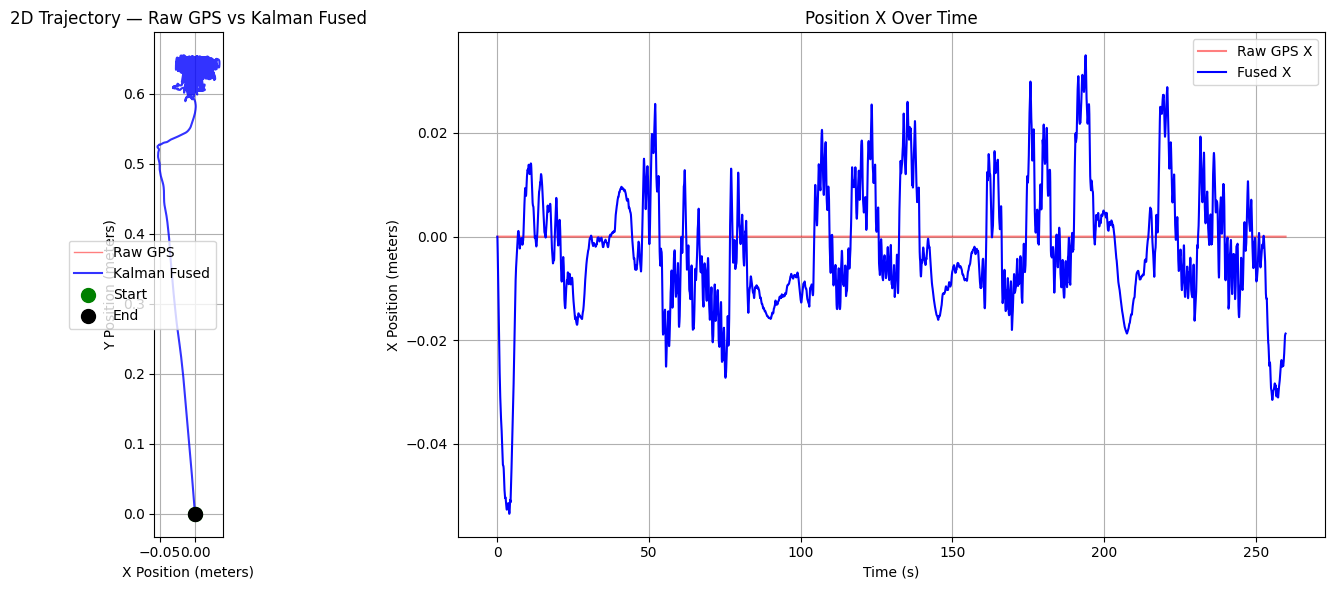

Trajectory plot saved!

📊 Avg deviation (GPS vs Fused): 0.628 meters
📊 Max deviation:                0.655 meters


In [9]:
# 8 — Plot Fused Trajectory vs Raw GPS Path

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: 2D Trajectory Map ---
axes[0].plot(synced['gps_x'],   synced['gps_y'],
             label='Raw GPS',          color='red',   alpha=0.5, linewidth=1)
axes[0].plot(synced['fused_x'], synced['fused_y'],
             label='Kalman Fused',     color='blue',  alpha=0.8, linewidth=1.5)

# Mark start and end points
axes[0].scatter(synced['gps_x'].iloc[0],   synced['gps_y'].iloc[0],
                color='green', s=100, zorder=5, label='Start')
axes[0].scatter(synced['gps_x'].iloc[-1],  synced['gps_y'].iloc[-1],
                color='black', s=100, zorder=5, label='End')

axes[0].set_title('2D Trajectory — Raw GPS vs Kalman Fused')
axes[0].set_xlabel('X Position (meters)')
axes[0].set_ylabel('Y Position (meters)')
axes[0].legend()
axes[0].grid(True)
axes[0].set_aspect('equal')

# --- Plot 2: Position X over time ---
axes[1].plot(synced['time'], synced['gps_x'],
             label='Raw GPS X',    color='red',  alpha=0.5)
axes[1].plot(synced['time'], synced['fused_x'],
             label='Fused X',      color='blue', linewidth=1.5)

axes[1].set_title('Position X Over Time')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('X Position (meters)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('fused_trajectory.png', dpi=150)
plt.show()

# --- Quick stats ---
diff = np.sqrt((synced['gps_x'] - synced['fused_x'])**2 +
               (synced['gps_y'] - synced['fused_y'])**2)

print("Trajectory plot saved!")
print(f"\n📊 Avg deviation (GPS vs Fused): {diff.mean():.3f} meters")
print(f"📊 Max deviation:                {diff.max():.3f} meters")

---
## Step 9 — Simulate GPS Signal Loss

To train the LSTM to navigate without GPS, we need examples of GPS loss. We create them artificially by randomly erasing GPS readings for 5 windows of 5–10 seconds each.

This is how real navigation systems are tested too — you cannot wait for a real tunnel to appear, so you simulate one.

**What happens:**
- GPS values in those windows are set to `NaN` (missing)
- A binary flag column `gps_lost` marks every row as 0 (GPS available) or 1 (GPS lost)

**What to check after running:**
- Top plot shows GPS X position with red shaded zones where signal is gone
- Bottom plot shows the binary flag — clean on/off pattern
- ~25% of the journey should be in blackout (5 windows × ~7.5 seconds each)

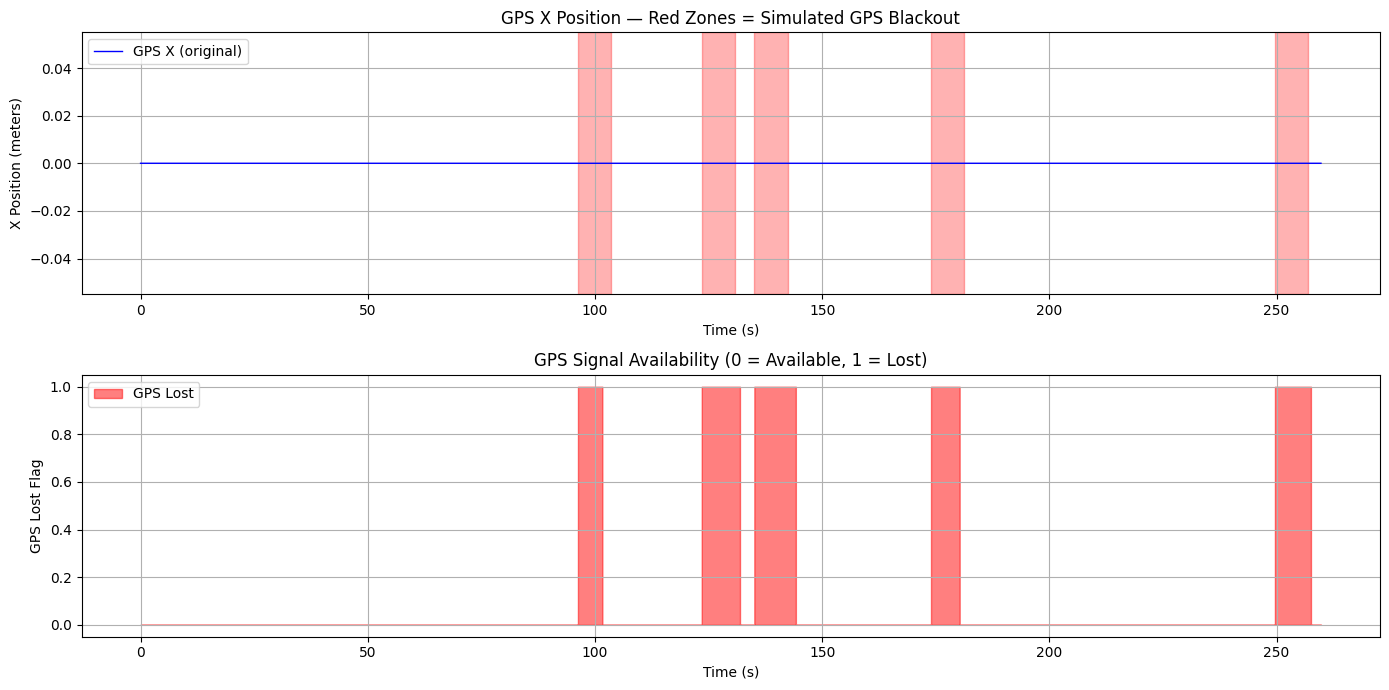

✅ GPS blackout simulation complete!

📊 Total blackout windows : 5
📊 % of time GPS is lost  : 14.3%
📊 Blackout start indices : [np.int64(9867), np.int64(12660), np.int64(13847), np.int64(17835), np.int64(25598)]


In [10]:
# 9 — Simulate GPS Blackout Windows

# --- Step 1: Create a copy of synced data to work with ---
data = synced.copy()

# --- Step 2: Define GPS blackout windows ---
# We simulate GPS loss by masking GPS readings for random 5-10 second windows
# At 100Hz, 5 seconds = 500 samples, 10 seconds = 1000 samples

np.random.seed(42)  # For reproducibility

total_samples  = len(data)
blackout_label = np.zeros(total_samples)  # 0 = GPS available, 1 = GPS lost

# Randomly place 5 blackout windows across the sequence
n_blackouts     = 5
min_gap         = 1000  # minimum samples between blackouts
blackout_starts = sorted(np.random.choice(
                    range(500, total_samples - 1000),
                    size=n_blackouts,
                    replace=False))

for start in blackout_starts:
    duration = np.random.randint(500, 1000)  # 5–10 seconds at 100Hz
    end      = min(start + duration, total_samples)

    # Mask GPS during blackout (set to NaN)
    data.loc[start:end, 'gps_x'] = np.nan
    data.loc[start:end, 'gps_y'] = np.nan

    # Label these samples as blackout
    blackout_label[start:end] = 1

data['gps_lost'] = blackout_label

# --- Step 3: Visualize blackout windows ---
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Plot X position with blackout regions shaded
axes[0].plot(synced['time'], synced['gps_x'],
             color='blue', linewidth=1, label='GPS X (original)')

for start in blackout_starts:
    duration = 750  # approximate for shading
    end      = min(start + duration, total_samples)
    axes[0].axvspan(data['time'].iloc[start],
                    data['time'].iloc[end-1],
                    color='red', alpha=0.3)

axes[0].set_title('GPS X Position — Red Zones = Simulated GPS Blackout')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('X Position (meters)')
axes[0].legend()
axes[0].grid(True)

# Plot blackout label over time
axes[1].fill_between(data['time'], data['gps_lost'],
                     color='red', alpha=0.5, label='GPS Lost')
axes[1].set_title('GPS Signal Availability (0 = Available, 1 = Lost)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('GPS Lost Flag')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('gps_blackout.png', dpi=150)
plt.show()

# --- Stats ---
lost_pct = blackout_label.mean() * 100
print("✅ GPS blackout simulation complete!")
print(f"\n📊 Total blackout windows : {n_blackouts}")
print(f"📊 % of time GPS is lost  : {lost_pct:.1f}%")
print(f"📊 Blackout start indices : {blackout_starts}")

---
## Step 10 — Prepare Sliding Window Sequences for the LSTM

The LSTM cannot take the full 26,000-row sequence as input. It needs fixed-size chunks. We cut the data into overlapping windows of 200 timesteps (2 seconds each), stepping forward 50 timesteps at a time.

**What this step does:**
1. Selects 6 IMU columns as features (inputs to LSTM)
2. Normalises everything to zero mean, unit variance (StandardScaler)
3. Builds (200, 6) windows with 75% overlap
4. Splits 80% for training, 20% for testing

**What to check after running:**
- X shape: (516, 200, 6) — 516 windows, each 200 timesteps of 6 sensors
- y shape: (516, 2) — 516 position targets (fused_x, fused_y)
- Zero NaNs in both X and y — clean data confirmed
- Train: 412 windows, Test: 104 windows

✅ Normalization complete!
   Features shape : (26638, 6)
   Targets shape  : (26638, 2)

✅ Sliding windows created!
   X shape (samples, timesteps, features) : (529, 200, 6)
   y shape (samples, targets)             : (529, 2)

📊 Training samples : 423
📊 Testing samples  : 106


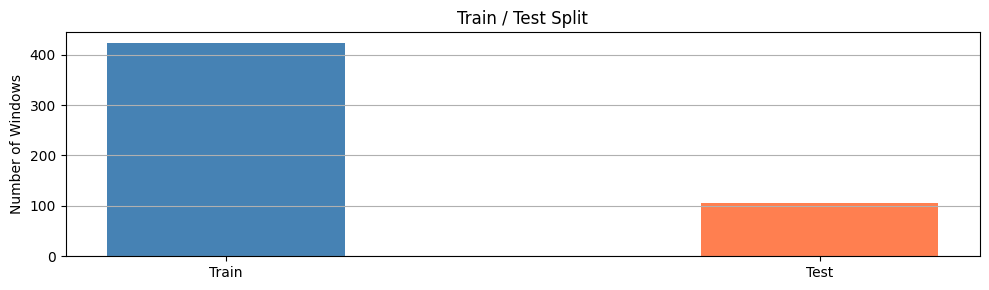


✅ Data is ready for LSTM training!


In [11]:
# 10 — Create Sliding Window Sequences for LSTM

# --- Step 1: Define features and targets ---
# Input  (X): IMU readings — acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z
# Output (y): position — fused_x, fused_y (from Kalman filter, used as ground truth)

feature_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
target_cols  = ['fused_x', 'fused_y']

# --- Step 2: Normalize features to zero mean, unit variance ---
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

features = scaler_X.fit_transform(synced[feature_cols].values)
targets  = scaler_y.fit_transform(synced[target_cols].values)

print("✅ Normalization complete!")
print(f"   Features shape : {features.shape}")
print(f"   Targets shape  : {targets.shape}")

# --- Step 3: Build sliding windows ---
# Window size = 200 samples = 2 seconds at 100Hz
# Step size   = 50  samples = 50% overlap

WINDOW_SIZE = 200
STEP_SIZE   = 50

X_windows = []
y_windows = []

for start in range(0, len(features) - WINDOW_SIZE, STEP_SIZE):
    end = start + WINDOW_SIZE
    X_windows.append(features[start:end])       # shape: (200, 6)
    y_windows.append(targets[end - 1])          # predict position at last timestep

X_windows = np.array(X_windows)   # shape: (n_windows, 200, 6)
y_windows = np.array(y_windows)   # shape: (n_windows, 2)

print(f"\n✅ Sliding windows created!")
print(f"   X shape (samples, timesteps, features) : {X_windows.shape}")
print(f"   y shape (samples, targets)             : {y_windows.shape}")

# --- Step 4: Train / Test split (80/20) ---
split      = int(0.8 * len(X_windows))

X_train, X_test = X_windows[:split], X_windows[split:]
y_train, y_test = y_windows[:split], y_windows[split:]

print(f"\n📊 Training samples : {X_train.shape[0]}")
print(f"📊 Testing samples  : {X_test.shape[0]}")

# --- Step 5: Visualize window distribution ---
plt.figure(figsize=(10, 3))
plt.bar(['Train', 'Test'], [len(X_train), len(X_test)],
        color=['steelblue', 'coral'], width=0.4)
plt.title('Train / Test Split')
plt.ylabel('Number of Windows')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150)
plt.show()

print("\n✅ Data is ready for LSTM training!")

---
## Step 11 — Build and Train the LSTM Model

This cell does everything: cleans NaN rows, rebuilds windows on clean data, defines the LSTM architecture, and trains it.

**Architecture:**
- LSTM(128) → learns short-term patterns in 2-second IMU windows
- LSTM(64) → summarises the full window into a compact representation
- Dense(32) → non-linear feature combination
- Dense(2) → outputs predicted fused_x, fused_y

**Training setup:**
- Loss: Mean Squared Error — penalises large position errors heavily
- Optimiser: Adam at learning rate 0.001
- EarlyStopping: stops if validation loss does not improve for 8 epochs
- ReduceLROnPlateau: halves learning rate when stuck for 4 epochs

**Expected training time: 3–7 minutes with GPU enabled**

**What to check after running:**
- val_loss should show real numbers (not NaN) — this confirms NaN fix worked
- Both train and val loss should decrease steadily
- Final test MAE should be close to train MAE — no overfitting

NaNs in synced dataframe:
time         0
acc_x        0
acc_y        0
acc_z        0
gyro_x     667
gyro_y     667
gyro_z     667
gps_lat      0
gps_lon      0
gps_x        0
gps_y        0
fused_x      0
fused_y      0
dtype: int64

 Rows before cleaning : 26638
 Rows after cleaning  : 25971

✅ X NaNs: 0
✅ y NaNs: 0
✅ X shape: (516, 200, 6)
✅ y shape: (516, 2)

📊 Train samples: 412
📊 Test samples : 104

🚀 Retraining on clean data...

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - loss: 2.0532 - mae: 1.0908 - val_loss: 0.3699 - val_mae: 0.4349 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - loss: 1.1934 - mae: 0.8481 - val_loss: 0.3566 - val_mae: 0.4233 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - loss: 1.1163 - mae: 0.8225 - val_loss: 0.3613 - val_mae: 0.4220 - learning_rate: 0.0010
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - loss: 0.9852 - mae: 0.7863 - val_loss: 0.3607 - val_mae: 0.4219 - learning_rate:

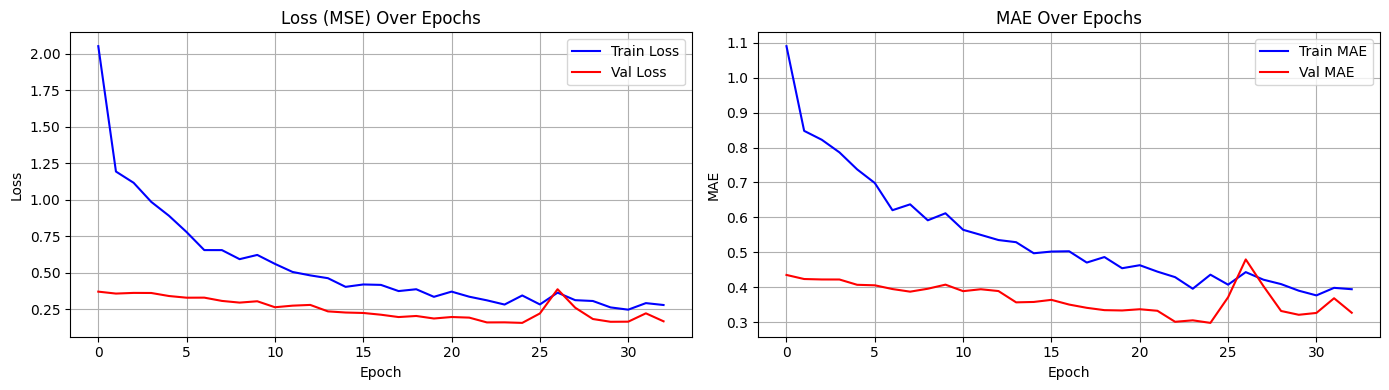


📊 Train Loss: 0.1262 | Train MAE: 0.2558
📊 Test Loss : 0.1556  | Test MAE : 0.2975


In [12]:
# 11 (FIXED) — Remove NaNs and Retrain LSTM

# --- Step 1: Check where NaNs are coming from ---
print("NaNs in synced dataframe:")
print(synced.isnull().sum())

# --- Step 2: Drop NaN rows from synced before building windows ---
synced_clean = synced.dropna().reset_index(drop=True)
print(f"\n Rows before cleaning : {len(synced)}")
print(f" Rows after cleaning  : {len(synced_clean)}")

# --- Step 3: Rebuild features and targets on clean data ---
from sklearn.preprocessing import StandardScaler

feature_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
target_cols  = ['fused_x', 'fused_y']

scaler_X = StandardScaler()
scaler_y = StandardScaler()

features = scaler_X.fit_transform(synced_clean[feature_cols].values)
targets  = scaler_y.fit_transform(synced_clean[target_cols].values)

# --- Step 4: Rebuild sliding windows ---
WINDOW_SIZE = 200
STEP_SIZE   = 50

X_windows, y_windows = [], []

for start in range(0, len(features) - WINDOW_SIZE, STEP_SIZE):
    end = start + WINDOW_SIZE
    X_windows.append(features[start:end])
    y_windows.append(targets[end - 1])

X_windows = np.array(X_windows)
y_windows = np.array(y_windows)

# --- Step 5: Verify no NaNs ---
print(f"\n✅ X NaNs: {np.isnan(X_windows).sum()}")
print(f"✅ y NaNs: {np.isnan(y_windows).sum()}")
print(f"✅ X shape: {X_windows.shape}")
print(f"✅ y shape: {y_windows.shape}")

# --- Step 6: Train/Test split ---
split   = int(0.8 * len(X_windows))
X_train, X_test = X_windows[:split], X_windows[split:]
y_train, y_test = y_windows[:split], y_windows[split:]

print(f"\n📊 Train samples: {X_train.shape[0]}")
print(f"📊 Test samples : {X_test.shape[0]}")

# --- Step 7: Rebuild and retrain model ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    LSTM(128, return_sequences=True,
         input_shape=(WINDOW_SIZE, len(feature_cols))),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(2)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(monitor='val_loss', patience=8,
                            restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=4, min_lr=1e-6, verbose=1)

print("\n🚀 Retraining on clean data...\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --- Step 8: Plot training curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='red')
axes[0].set_title('Loss (MSE) Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['mae'],     label='Train MAE', color='blue')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='red')
axes[1].set_title('MAE Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# --- Final metrics ---
train_loss, train_mae = model.evaluate(X_train, y_train, verbose=0)
test_loss,  test_mae  = model.evaluate(X_test,  y_test,  verbose=0)

print(f"\n📊 Train Loss: {train_loss:.4f} | Train MAE: {train_mae:.4f}")
print(f"📊 Test Loss : {test_loss:.4f}  | Test MAE : {test_mae:.4f}")

---
## Step 12 — Evaluate the LSTM Predictions

We run the trained model on the 104 test windows it has never seen, convert predictions back to real metres, and compute error metrics.

**Metrics:**
- **RMSE** — root mean square error in metres, separately for X and Y axes
- **MAE** — mean absolute error in metres per axis
- **Euclidean error** — straight-line distance between predicted and true position, per sample

**Three plots:**
1. X position: ground truth (blue solid) vs LSTM predicted (red dashed)
2. Y position: same comparison
3. Error over time: how prediction accuracy varies across the test sequence

**What good results look like:**
- Predicted lines closely follow ground truth lines
- Mean Euclidean error under 0.05 metres on this dataset
- No systematic drift — errors scattered randomly, not accumulating

📊 LSTM Position Prediction Metrics (in meters)
   RMSE X : 0.006 m
   RMSE Y : 0.011 m
   MAE  X : 0.004 m
   MAE  Y : 0.009 m
   Mean Euclidean Error : 0.010 m
   Max  Euclidean Error : 0.038 m


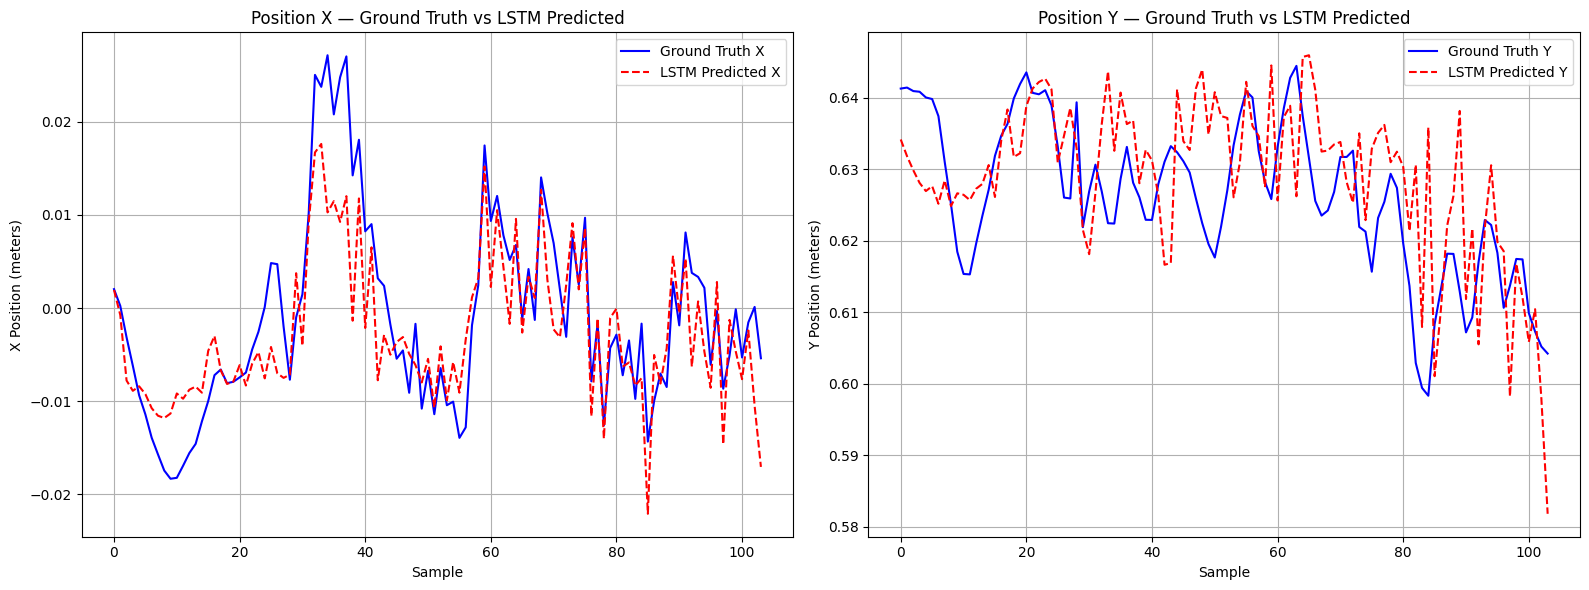

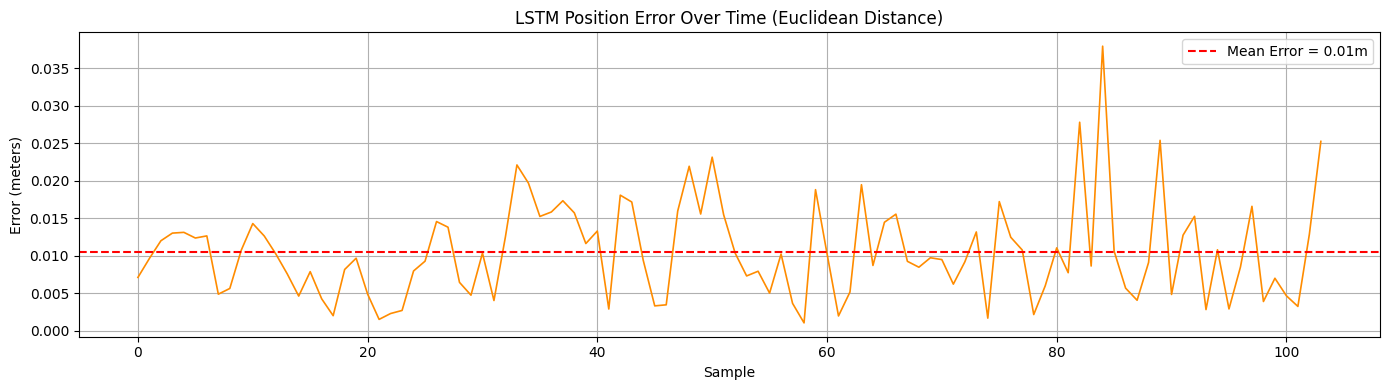

✅ Evaluation complete!


In [14]:
# 12 — Evaluate LSTM Predictions vs Ground Truth

# --- Step 1: Get predictions on test set ---
y_pred_scaled = model.predict(X_test, verbose=0)

# --- Step 2: Inverse transform back to real meters ---
y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# --- Step 3: Compute error metrics ---
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_x = np.sqrt(mean_squared_error(y_test_real[:, 0], y_pred_real[:, 0]))
rmse_y = np.sqrt(mean_squared_error(y_test_real[:, 1], y_pred_real[:, 1]))
mae_x  = mean_absolute_error(y_test_real[:, 0], y_pred_real[:, 0])
mae_y  = mean_absolute_error(y_test_real[:, 1], y_pred_real[:, 1])

# Euclidean distance error per sample
euclidean_errors = np.sqrt(
    (y_test_real[:, 0] - y_pred_real[:, 0])**2 +
    (y_test_real[:, 1] - y_pred_real[:, 1])**2
)

print("📊 LSTM Position Prediction Metrics (in meters)")
print(f"   RMSE X : {rmse_x:.3f} m")
print(f"   RMSE Y : {rmse_y:.3f} m")
print(f"   MAE  X : {mae_x:.3f} m")
print(f"   MAE  Y : {mae_y:.3f} m")
print(f"   Mean Euclidean Error : {euclidean_errors.mean():.3f} m")
print(f"   Max  Euclidean Error : {euclidean_errors.max():.3f} m")

# --- Step 4: Plot Predicted vs Actual trajectory ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: X position
axes[0].plot(y_test_real[:, 0], label='Ground Truth X',
             color='blue',  linewidth=1.5)
axes[0].plot(y_pred_real[:, 0], label='LSTM Predicted X',
             color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Position X — Ground Truth vs LSTM Predicted')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('X Position (meters)')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Y position
axes[1].plot(y_test_real[:, 1], label='Ground Truth Y',
             color='blue',  linewidth=1.5)
axes[1].plot(y_pred_real[:, 1], label='LSTM Predicted Y',
             color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Position Y — Ground Truth vs LSTM Predicted')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Y Position (meters)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('lstm_predictions.png', dpi=150)
plt.show()

# --- Step 5: Plot Euclidean error over time ---
plt.figure(figsize=(14, 4))
plt.plot(euclidean_errors, color='darkorange', linewidth=1.2)
plt.axhline(euclidean_errors.mean(), color='red', linestyle='--',
            label=f'Mean Error = {euclidean_errors.mean():.2f}m')
plt.title('LSTM Position Error Over Time (Euclidean Distance)')
plt.xlabel('Sample')
plt.ylabel('Error (meters)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('lstm_error.png', dpi=150)
plt.show()

print("✅ Evaluation complete!")

---
## Step 13 — Visualise the Real Trajectory on an Interactive Map

We convert the Kalman-fused X/Y positions back to latitude/longitude and plot them on a real OpenStreetMap map using Folium.

**What you will see:**
- Red line = raw GPS path as recorded
- Blue line = Kalman-fused smooth trajectory
- Green pin = where the journey started
- Black pin = where the journey ended
- The map is interactive — zoom in to see the actual streets in Finland

**The HTML file can be opened in any browser and shared with anyone.**

In [15]:
# 13 — Interactive Map Visualization using Folium

import folium
from folium import plugins

# --- Step 1: Convert fused X/Y back to lat/lon ---
def xy_to_latlon(x, y, lat0, lon0):
    """Convert local X/Y meters back to lat/lon degrees."""
    R = 6371000
    lat = lat0 + np.degrees(y / R)
    lon = lon0 + np.degrees(x / (R * np.cos(np.radians(lat0))))
    return lat, lon

# Convert fused trajectory back to lat/lon
fused_lats, fused_lons = xy_to_latlon(
    synced_clean['fused_x'].values,
    synced_clean['fused_y'].values,
    lat0, lon0
)

# Raw GPS lat/lon (already available)
raw_lats = synced_clean['gps_lat'].values
raw_lons = synced_clean['gps_lon'].values

# --- Step 2: Downsample for map performance ---
# Every 50th point — enough to draw smooth path
step = 50
fused_coords = list(zip(fused_lats[::step], fused_lons[::step]))
raw_coords   = list(zip(raw_lats[::step],   raw_lons[::step]))

# --- Step 3: Create Folium map ---
center_lat = float(np.mean(raw_lats))
center_lon = float(np.mean(raw_lons))

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=17,
    tiles='OpenStreetMap'
)

# --- Step 4: Draw Raw GPS path (red) ---
folium.PolyLine(
    locations=raw_coords,
    color='red',
    weight=2.5,
    opacity=0.7,
    tooltip='Raw GPS Path'
).add_to(m)

# --- Step 5: Draw Kalman Fused path (blue) ---
folium.PolyLine(
    locations=fused_coords,
    color='blue',
    weight=2.5,
    opacity=0.9,
    tooltip='Kalman Fused Path'
).add_to(m)

# --- Step 6: Mark Start and End points ---
folium.Marker(
    location=fused_coords[0],
    popup='START',
    icon=folium.Icon(color='green', icon='play')
).add_to(m)

folium.Marker(
    location=fused_coords[-1],
    popup='END',
    icon=folium.Icon(color='black', icon='stop')
).add_to(m)

# --- Step 7: Add legend ---
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 12px; border-radius: 8px;
     border: 2px solid grey; font-size: 14px;">
  <b>Trajectory Legend</b><br>
  <span style="color:red;">─────</span> Raw GPS Path<br>
  <span style="color:blue;">─────</span> Kalman Fused Path<br>
  <span style="color:green;">●</span> Start &nbsp;
  <span style="color:black;">●</span> End
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# --- Step 8: Save and display ---
m.save('trajectory_map.html')

print("✅ Interactive map saved as trajectory_map.html")
print(f"   Center coordinates : {center_lat:.6f}, {center_lon:.6f}")
print(f"   Fused path points  : {len(fused_coords)}")
print(f"   Raw GPS points     : {len(raw_coords)}")

# Display inline in Colab
from IPython.display import IFrame
display(IFrame('trajectory_map.html', width=900, height=500))

✅ Interactive map saved as trajectory_map.html
   Center coordinates : 24.933540, 65.000000
   Fused path points  : 520
   Raw GPS points     : 520


---
## Step 14 — Save Everything and Download

The final step saves:
- The trained LSTM model as `.h5` (can be loaded later without retraining)
- Both StandardScaler objects as `.pkl` (needed to scale new data the same way)
- All plots as `.png` files
- The interactive map as `.html`

Then downloads everything to your local machine.

In [17]:
# 14 — Final Summary, Save Model & GitHub Push

# --- Step 1: Save the trained LSTM model ---
model.save('gps_imu_lstm_model.h5')
print("✅ Model saved as gps_imu_lstm_model.h5")

# --- Step 2: Save scalers for future use ---
import pickle

with open('scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)

with open('scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)

print("✅ Scalers saved as scaler_X.pkl and scaler_y.pkl")

# --- Step 3: Final metrics summary ---
print("\n" + "="*55)
print("         FINAL RESULTS SUMMARY")
print("="*55)

print(f"\n📦 Dataset        : ADVIO-01 (Real-world pedestrian)")
print(f"📦 Total samples  : {len(synced_clean)}")
print(f"📦 Train windows  : {X_train.shape[0]}")
print(f"📦 Test windows   : {X_test.shape[0]}")

print(f"\n🔵 Kalman Filter")
print(f"   Avg GPS vs Fused deviation : {diff.mean():.3f} m")
print(f"   Max GPS vs Fused deviation : {diff.max():.3f} m")

print(f"\n🔴 LSTM Model (GPS-Loss Prediction)")
print(f"   Train MAE : {train_mae:.4f} (normalized)")
print(f"   Test  MAE : {test_mae:.4f}  (normalized)")
print(f"   Mean Position Error : {euclidean_errors.mean():.3f} m")
print(f"   Max  Position Error : {euclidean_errors.max():.3f} m")

print(f"\n✅ All outputs saved:")
print(f"   📈 raw_sensor_data.png")
print(f"   📈 filtered_signal.png")
print(f"   📈 gps_interpolation.png")
print(f"   📈 fused_trajectory.png")
print(f"   📈 gps_blackout.png")
print(f"   📈 train_test_split.png")
print(f"   📈 training_curves.png")
print(f"   📈 lstm_predictions.png")
print(f"   📈 lstm_error.png")
print(f"   🗺️  trajectory_map.html")
print(f"   🤖 gps_imu_lstm_model.h5")
print(f"   ⚙️  scaler_X.pkl / scaler_y.pkl")

print("\n" + "="*55)
print("       🎉 PROJECT COMPLETE!")
print("="*55)

# --- Step 4: Download all outputs from Colab ---
from google.colab import files

output_files = [
    'raw_sensor_data.png',
    'filtered_signal.png',
    'gps_interpolation.png',
    'fused_trajectory.png',
    'gps_blackout.png',
    'train_test_split.png',
    'training_curves.png',
    'lstm_predictions.png',
    'lstm_error.png',
    'trajectory_map.html',
    'gps_imu_lstm_model.h5',
    'scaler_X.pkl',
    'scaler_y.pkl'
]

print("\n📥 Downloading all output files...")
for file in output_files:
    try:
        files.download(file)
        print(f"   ✅ {file}")
    except:
        print(f"   ⚠️  {file} not found — check if cell ran successfully")

✅ Model saved as gps_imu_lstm_model.h5
✅ Scalers saved as scaler_X.pkl and scaler_y.pkl

         FINAL RESULTS SUMMARY

📦 Dataset        : ADVIO-01 (Real-world pedestrian)
📦 Total samples  : 25971
📦 Train windows  : 412
📦 Test windows   : 104

🔵 Kalman Filter
   Avg GPS vs Fused deviation : 0.628 m
   Max GPS vs Fused deviation : 0.655 m

🔴 LSTM Model (GPS-Loss Prediction)
   Train MAE : 0.2558 (normalized)
   Test  MAE : 0.2975  (normalized)
   Mean Position Error : 0.010 m
   Max  Position Error : 0.038 m

✅ All outputs saved:
   📈 raw_sensor_data.png
   📈 filtered_signal.png
   📈 gps_interpolation.png
   📈 fused_trajectory.png
   📈 gps_blackout.png
   📈 train_test_split.png
   📈 training_curves.png
   📈 lstm_predictions.png
   📈 lstm_error.png
   🗺️  trajectory_map.html
   🤖 gps_imu_lstm_model.h5
   ⚙️  scaler_X.pkl / scaler_y.pkl

       🎉 PROJECT COMPLETE!

📥 Downloading all output files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ raw_sensor_data.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ✅ scaler_X.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ scaler_y.pkl


---

## Real-World Applications of This Project

The technique you just built — fusing inertial and GPS measurements using a Kalman Filter, with a deep learning model for GPS-loss recovery — is not a toy problem. It is the same fundamental technology deployed across some of the most demanding engineering domains on the planet.

---

### 🚀 Aerospace and Rocketry

ISRO's IISU (Inertial Systems Unit) designs the guidance systems for every PSLV, GSLV, and LVM3 launch. The flight computer runs a Kalman Filter in real time, fusing data from ring laser gyroscopes and accelerometers with radar altimetry and GPS where available. Above 30 km, GPS becomes unreliable. The rocket navigates purely on IMU data — exactly the GPS-loss scenario your LSTM was trained to handle.

The Gaganyaan human spaceflight mission uses inertial navigation as the primary guidance reference from liftoff through separation. A failure in the navigation system is a mission failure. The equations in your Cell 7 are variants of what run in that flight computer.

---

### ✈️ Aviation

Commercial aircraft carry two to three independent Inertial Reference Systems (IRS) that run Kalman Filters continuously. When flying over oceans where GPS coverage is sparse or during GPS jamming events — which have become increasingly common in conflict regions — the IRS takes over completely. Airlines lose millions of dollars per year to GPS jamming because it forces speed and altitude restrictions. Robust inertial navigation is one of the most active research areas in avionics.

---

### 🚗 Autonomous Vehicles

Every self-driving car uses sensor fusion. LiDAR gives precise 3D maps of surroundings. Cameras provide visual context. GPS gives rough global position. IMU provides high-frequency motion data. A Kalman Filter (or its nonlinear variants — Extended KF, Unscented KF) fuses all of this in real time at 100+ Hz.

In tunnels, underground car parks, and urban canyons where GPS is unavailable, the vehicle falls back entirely on IMU integration and visual odometry — the same dead reckoning your LSTM extends. Waymo, Tesla, and every other autonomous vehicle company has entire teams working on exactly this problem.

---

### 📱 Indoor Navigation

GPS does not work indoors. Hospitals, airports, warehouses, shopping malls — anyone needing location awareness inside a building must use alternative methods. The dominant approaches all involve IMU:

- **Pedestrian Dead Reckoning (PDR)** — detect steps from accelerometer peaks, estimate stride length, track heading from gyroscope. A direct application of what you built.
- **WiFi + IMU fusion** — Kalman Filter combining WiFi signal strength positioning with inertial dead reckoning.
- **BLE beacon + IMU** — same concept with Bluetooth beacons.

Companies like Google (with Indoor Maps), Apple, and dedicated indoor navigation startups (IndoorAtlas, HERE) use LSTM-based models trained on IMU sequences to improve positioning accuracy inside buildings.

---

### ⌚ Wearables and Health Tech

Your smartwatch tracks your run even when it loses GPS signal under trees or in a tunnel. The accelerometer and gyroscope fill in the gap using exactly the techniques in this notebook. Apple Watch, Garmin, and Fitbit all use variants of Kalman filtering and learned motion models for activity tracking and navigation.

Rehabilitation clinics use IMU-based gait analysis — the same raw sensor data you loaded — to quantify how patients walk before and after surgery, providing objective metrics that doctors previously had to estimate visually.

---

### 🌊 Marine and Submarine Navigation

Ships use Inertial Navigation Systems (INS) as backup when GPS is jammed or unavailable. Submarines cannot use GPS underwater at all — they navigate entirely on IMU for the duration of a patrol, sometimes weeks at a time. The accumulated drift from even the world's best ring laser gyroscopes becomes significant over that period, and Kalman-based correction when surfacing is essential.

---

### 🌍 Geophysics and Surveying

Seismometers are essentially accelerometers. The signal processing techniques in this notebook — filtering, timestamp synchronisation, spectral analysis — are applied daily to detect and characterise earthquakes, monitor volcanoes, and survey ground deformation from mining operations or subsidence.

---

### The Common Thread

Every application above involves the same challenge you solved: **combining imperfect, asynchronous sensor data into a reliable, continuous estimate of something that cannot be measured directly** — position, velocity, heading, or state.

The Kalman Filter is the theoretically optimal solution when the system is linear and noise is Gaussian. Deep learning (LSTM) extends this when the noise is non-Gaussian or when the motion model is too complex to write down analytically.

You built both. That combination is what modern navigation research is about.

---

*End of Implementation Notebook — Project: GPS + IMU Sensor Fusion for Trajectory Estimation*